In [ ]:
!pip install control zplane

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 549.6/549.6 kB 7.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from scipy import signal, datasets
import control
import zplane
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
ecg = datasets.electrocardiogram()
ecg

array([-0.245, -0.215, -0.185, ..., -0.405, -0.395, -0.385])

In [ ]:
help(datasets)

Help on package scipy.datasets in scipy:

NAME
    scipy.datasets

DESCRIPTION
    Datasets (:mod:`scipy.datasets`)
    
    .. currentmodule:: scipy.datasets
    
    Dataset Methods
    
    .. autosummary::
       :toctree: generated/
    
       ascent
       face
       electrocardiogram
    
    Utility Methods
    
    .. autosummary::
       :toctree: generated/
    
       download_all    -- Download all the dataset files to specified path.
       clear_cache     -- Clear cached dataset directory.
    
    
    Usage of Datasets
    
    SciPy dataset methods can be simply called as follows: ``'<dataset-name>()'``
    This downloads the dataset files over the network once, and saves the cache,
    before returning a `numpy.ndarray` object representing the dataset.
    
    Note that the return data structure and data type might be different for
    different dataset methods. For a more detailed example on usage, please look
    into the particular dataset method documentation 

In [ ]:
fs = 360
time = np.arange(ecg.size) / fs

# extrasystoles
  After second 16, however, the first premature ventricular contractions,
        also called extrasystoles, appear. These have a different morphology
        compared to typical heartbeats. The difference can easily be observed
        in the following plot.
        


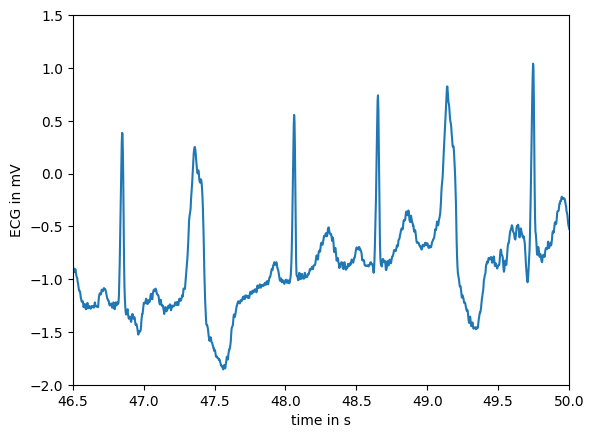

In [ ]:
plt.plot(time, ecg)
plt.xlabel("time in s")
plt.ylabel("ECG in mV")
plt.xlim(46.5, 50)
plt.ylim(-2, 1.5)
plt.show()

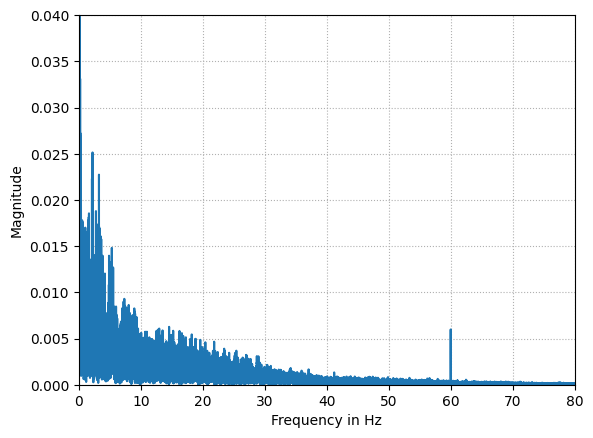

In [ ]:
plt.magnitude_spectrum(ecg, Fs=fs)
plt.xlabel("Frequency in Hz")
plt.ylabel("Magnitude")
plt.xlim(0,80)
plt.ylim(0, 0.04)
plt.grid(ls=":")
plt.show()

In [ ]:
np.where(time==46.5), np.where(time==50),

((array([16740]),), (array([18000]),))

In [ ]:
# filtrar por los tiempos
time = time[16740: 18000]
ecg = ecg[16740: 18000]


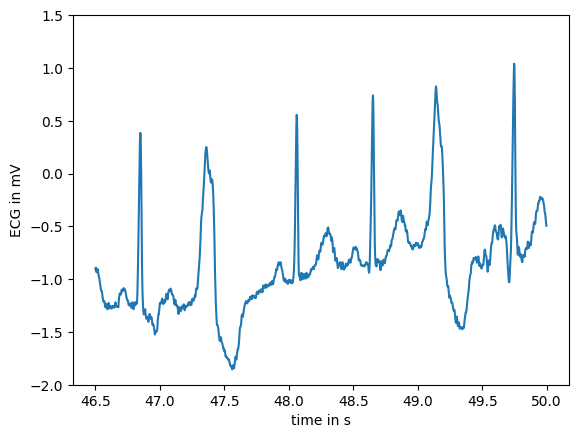

In [ ]:
plt.plot(time, ecg)
plt.xlabel("time in s")
plt.ylabel("ECG in mV")
plt.ylim(-2, 1.5)
plt.show()

## señal + ruido

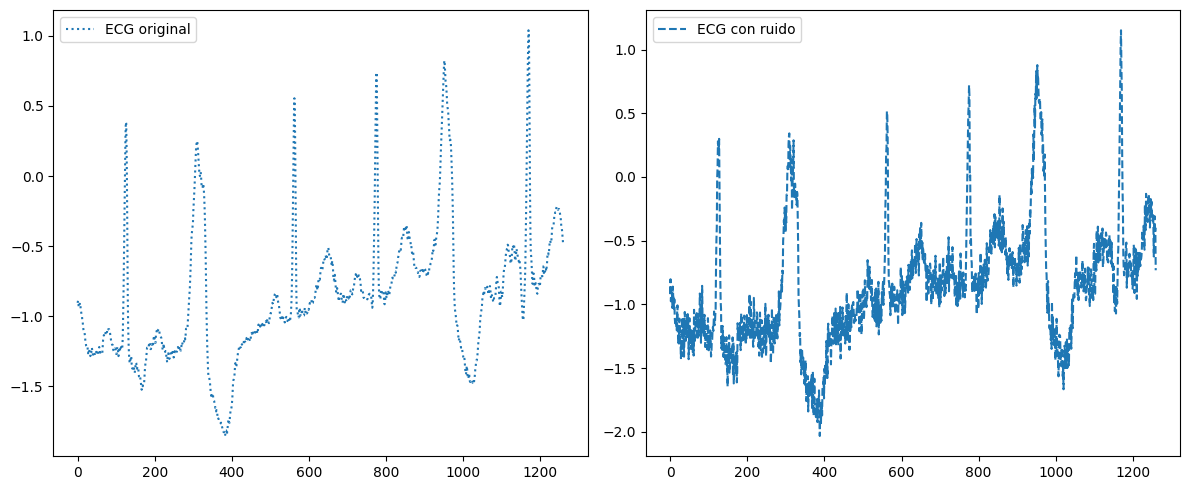

In [ ]:
# prompt: agrega ruiso gausiano a la variable ecg

# Agrega ruido gaussiano a la señal ECG
ruido = np.random.normal(0, 0.1, ecg.shape[0])
ecg_ruidosa = ecg + ruido

# Grafica la señal original y la señal con ruido
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.plot(ecg, label='ECG original', linestyle=':')
plt.legend()

plt.subplot(1,2,2)
plt.plot(ecg_ruidosa, label='ECG con ruido', linestyle='--')
plt.legend()

plt.tight_layout()
plt.show()


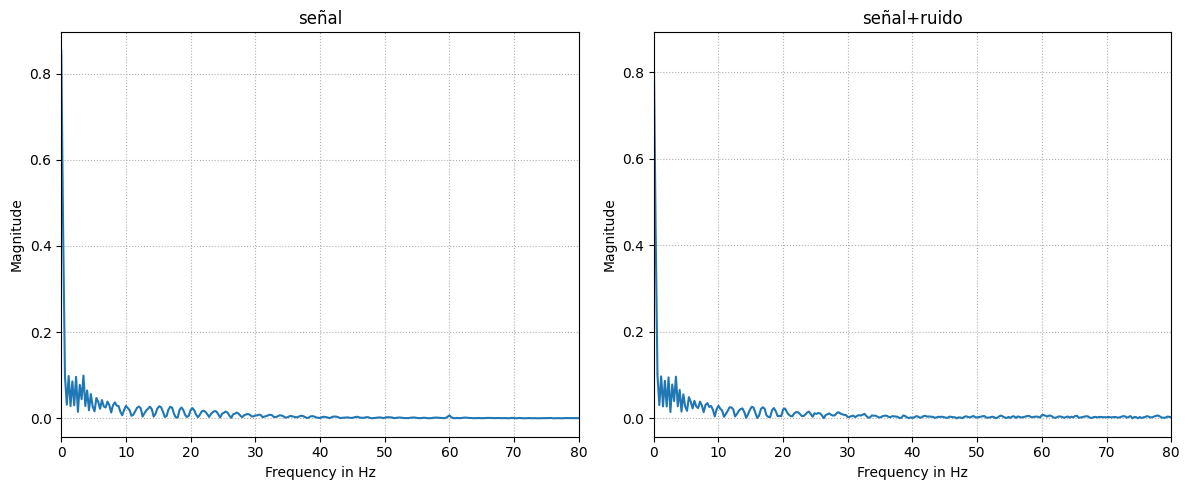

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1,2,1)
plt.title("señal")
plt.magnitude_spectrum(ecg, Fs=fs)
plt.xlabel("Frequency in Hz")
plt.ylabel("Magnitude")
plt.xlim(0,80)
#plt.ylim(0, 0.04)
plt.grid(ls=":")
#plt.show()

plt.subplot(1,2,2)
plt.title("señal+ruido")
plt.magnitude_spectrum(ecg_ruidosa, Fs=fs)
plt.xlabel("Frequency in Hz")
plt.ylabel("Magnitude")
plt.xlim(0,80)
#plt.ylim(0, 0.04)
plt.grid(ls=":")

# Ajustar el espacio entre los subplots
plt.tight_layout()
plt.show()

# Diseño de filtro FIR

In [ ]:
ecg.shape

(1260,)

In [ ]:
#longitud de la ventana
M = 37
#frecuencia de corte en Hz
Fc = 40

#Frecuencia de corte en radianes
wc = 2*np.pi*Fc/fs

# filtro fir
w = signal.firwin(numtaps=M, cutoff=Fc, pass_zero='lowpass',window='hamming', fs=fs)
w = np.round(w,3)

In [ ]:
y = signal.lfilter(w, np.array(1),ecg_ruidosa)

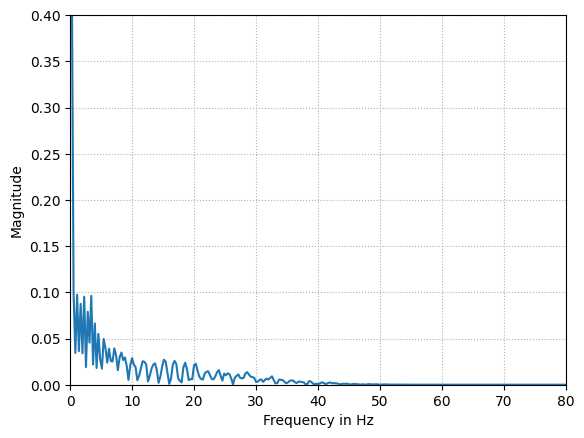

In [ ]:
plt.magnitude_spectrum(y, Fs=fs)
plt.xlabel("Frequency in Hz")
plt.ylabel("Magnitude")
plt.xlim(0,80)
plt.ylim(0, 0.4)
plt.grid(ls=":")
plt.show()

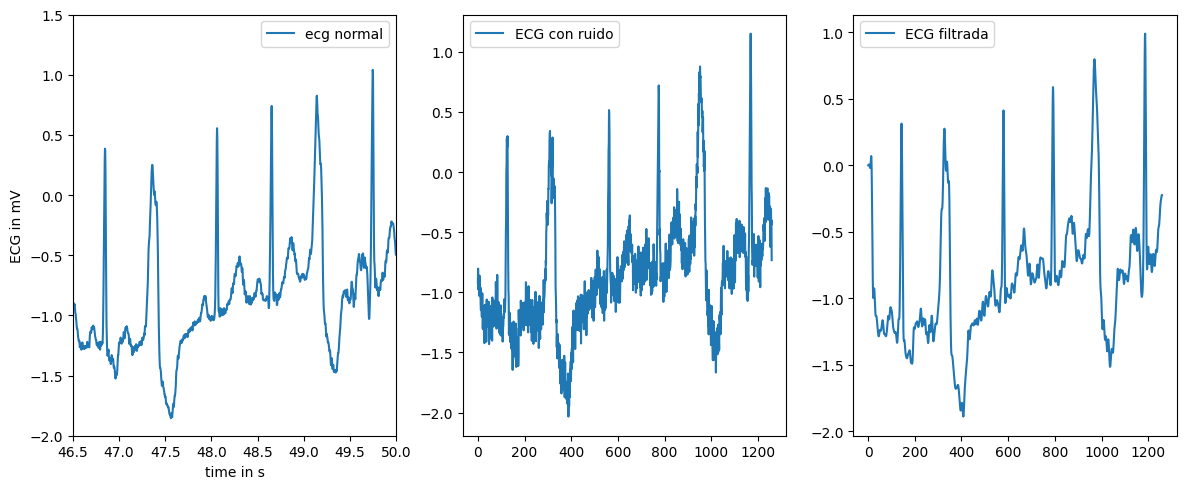

In [ ]:
plt.figure(figsize=(12, 5))


plt.subplot(1,3,1)
plt.plot(time, ecg, label="ecg normal")
plt.xlabel("time in s")
plt.ylabel("ECG in mV")
plt.xlim(46.5, 50)
plt.ylim(-2, 1.5)
plt.legend()

plt.subplot(1,3,2)
plt.plot(ecg_ruidosa, label='ECG con ruido')
plt.legend()

plt.subplot(1,3,3)
plt.plot(y, label='ECG filtrada')
plt.legend()

plt.tight_layout()

plt.show()

In [ ]:
, .